In [65]:
import importlib.util
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

import importlib
import analytics
importlib.reload(analytics)

<module 'analytics' from '/Users/gab/Library/Mobile Documents/com~apple~CloudDocs/QuIST/Projekt-Praktikum/codebase/groundstate_prep/analytics.py'>

In [89]:
### H_params = [J, h, N]
H_params = [1., 2., 4]

### T_params = [T, tau]
T_params = [1., 0.2]

### C_params = [alpha, sigma, omega_max]
#C_params = [0.35, .2, 4.0] -> to wrong fixpoint

C_params = [0.35, .2, 6.0]

#### inverse temperature
beta = 0.2

[5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100]

--------------------------------------------------------------------------------
Start calculation
--------------------------------------------------------------------------------

Transversal Ising XXZ model on 4 qubits with J = 1.0 , h = 2.0 :

H_sys = -1.0 * (Z(0) @ Z(1)) + -1.0 * (Z(1) @ Z(2)) + -1.0 * (Z(2) @ Z(3)) + -1.0 * (Z(3) @ Z(0)) + -2.0 * X(0) + -2.0 * X(1) + -2.0 * X(2) + -2.0 * X(3) 

5  timesteps:	 0.707
10  timesteps:	 0.527
					 trace dist. increment 0.643
15  timesteps:	 0.437
					 trace dist. increment 0.508
20  timesteps:	 0.351
					 trace dist. increment 0.425
25  timesteps:	 0.257
					 trace dist. increment 0.35
30  timesteps:	 0.208
					 trace dist. increment 0.27
35  timesteps:	 0.18
					 trace dist. increment 0.207
40  timesteps:	 0.138
					 trace dist. increment 0.161
45  timesteps:	 0.116
					 trace dist. increment 0.127
50  timesteps:	 0.105
					 trace dist. increment

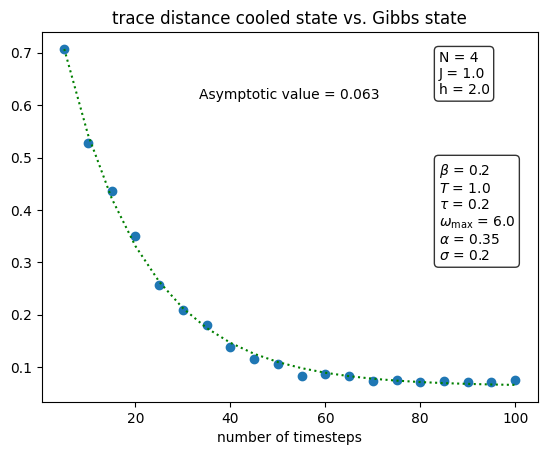

In [90]:
N=20
t = [5*i for i in range(1,N+1)]
print(t)

t, dist, increments, p = analytics.run_TFIM(H_params, T_params, C_params, beta, timesteps=t)
_, p_fit, cov = analytics.extract_asymptotics(t, dist)

54.0 iterations necessary for level eps <  0.1


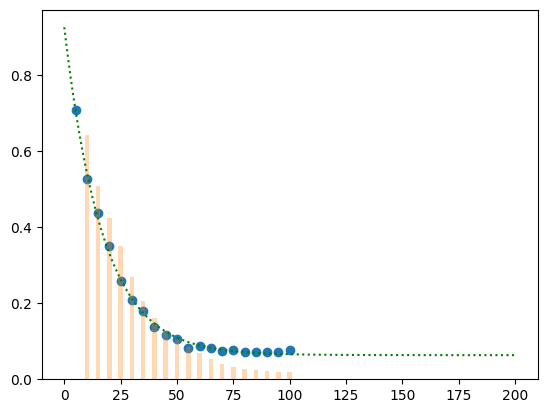

In [92]:
x = np.linspace(0,200,201)
y = analytics.exp_model(x, *p_fit)

fig, ax = plt.subplots()

ax.scatter(t, dist)
ax.plot(x,y, color="green", ls=":")
ax.bar(t[1:], increments[1:], width=2, alpha=0.3, label="increments")


level = 0.1
a, b, c = p_fit
if level>a:
    n = np.log((level - a) / b) / c
    print(np.ceil(n), 'iterations necessary for level eps < ', level)
else:
    print("level", level, "not reachable")

In [ ]:
beta = 0.2

T_params_sweep = [ [1, tau] for tau in [0.1]]
C_params_sweep = [[0.35, i/10, 6] for i in range(1,21)] 

i = 1
results = []
print(len(T_params_sweep)*len(C_params_sweep), "sweeps:\n")
for C_params in C_params_sweep:
    for T_params in T_params_sweep:
        res = analytics.run_TFIM(H_params, T_params, C_params, beta, timesteps=80, silent=True, plots=False) 
        print("sweep", i, ": ", res[1][-1])
        results.append(res)
        i += 1

values = [res[1][-1] for res in results]
idx = np.argmin(values)
best = results[idx]
print(best[3])

18 sweeps:

sweep 1 :  0.6047073070258008
sweep 2 :  0.5373747880371954
sweep 3 :  0.3899216417743074
sweep 4 :  0.33800128864113876
sweep 5 :  0.2265934196606224
sweep 6 :  0.2384092928315999
sweep 7 :  0.12565571392682834
sweep 8 :  0.20797190734922152
sweep 9 :  0.08137714460604945
sweep 10 :  0.21056069752866008
sweep 11 :  0.07241184236592113
sweep 12 :  0.21872780947234702
sweep 13 :  0.0767681936339778
sweep 14 :  0.22586608756544507
sweep 15 :  0.08221448965742698
sweep 16 :  0.2312939753540158
sweep 17 :  0.08594800252782545
sweep 18 :  0.2357785789127092
{'N': 4, 'J': 1.0, 'h': 2.0, 'beta': 0.2, 'T': 1, 'tau': 0.2, 'alpha': 0.35, 'sigma': 0.2, 'omega_max': 6, 'ops': 'XZ', 'mixed': True, 'seed': 12}
